# AI Interpretability's Dead Salmons (Notebook)

*Author: Valentina Staneva*

Adapted from an exploratory notebook by [Jesse Hartman](https://www.linkedin.com/in/jesse-ryan-hartman/).


In [ ]:
pip install --quiet marimo

In [ ]:
import marimo as mo

In [ ]:
!gdown --id 1I4nRhvYoGciCW_KPBkz8rzswlXshD5f8


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1I4nRhvYoGciCW_KPBkz8rzswlXshD5f8
To: /content/salmon.png
100% 278k/278k [00:00<00:00, 28.8MB/s]


## Exploring Statistical Fragility

_FlexContainerHtml()
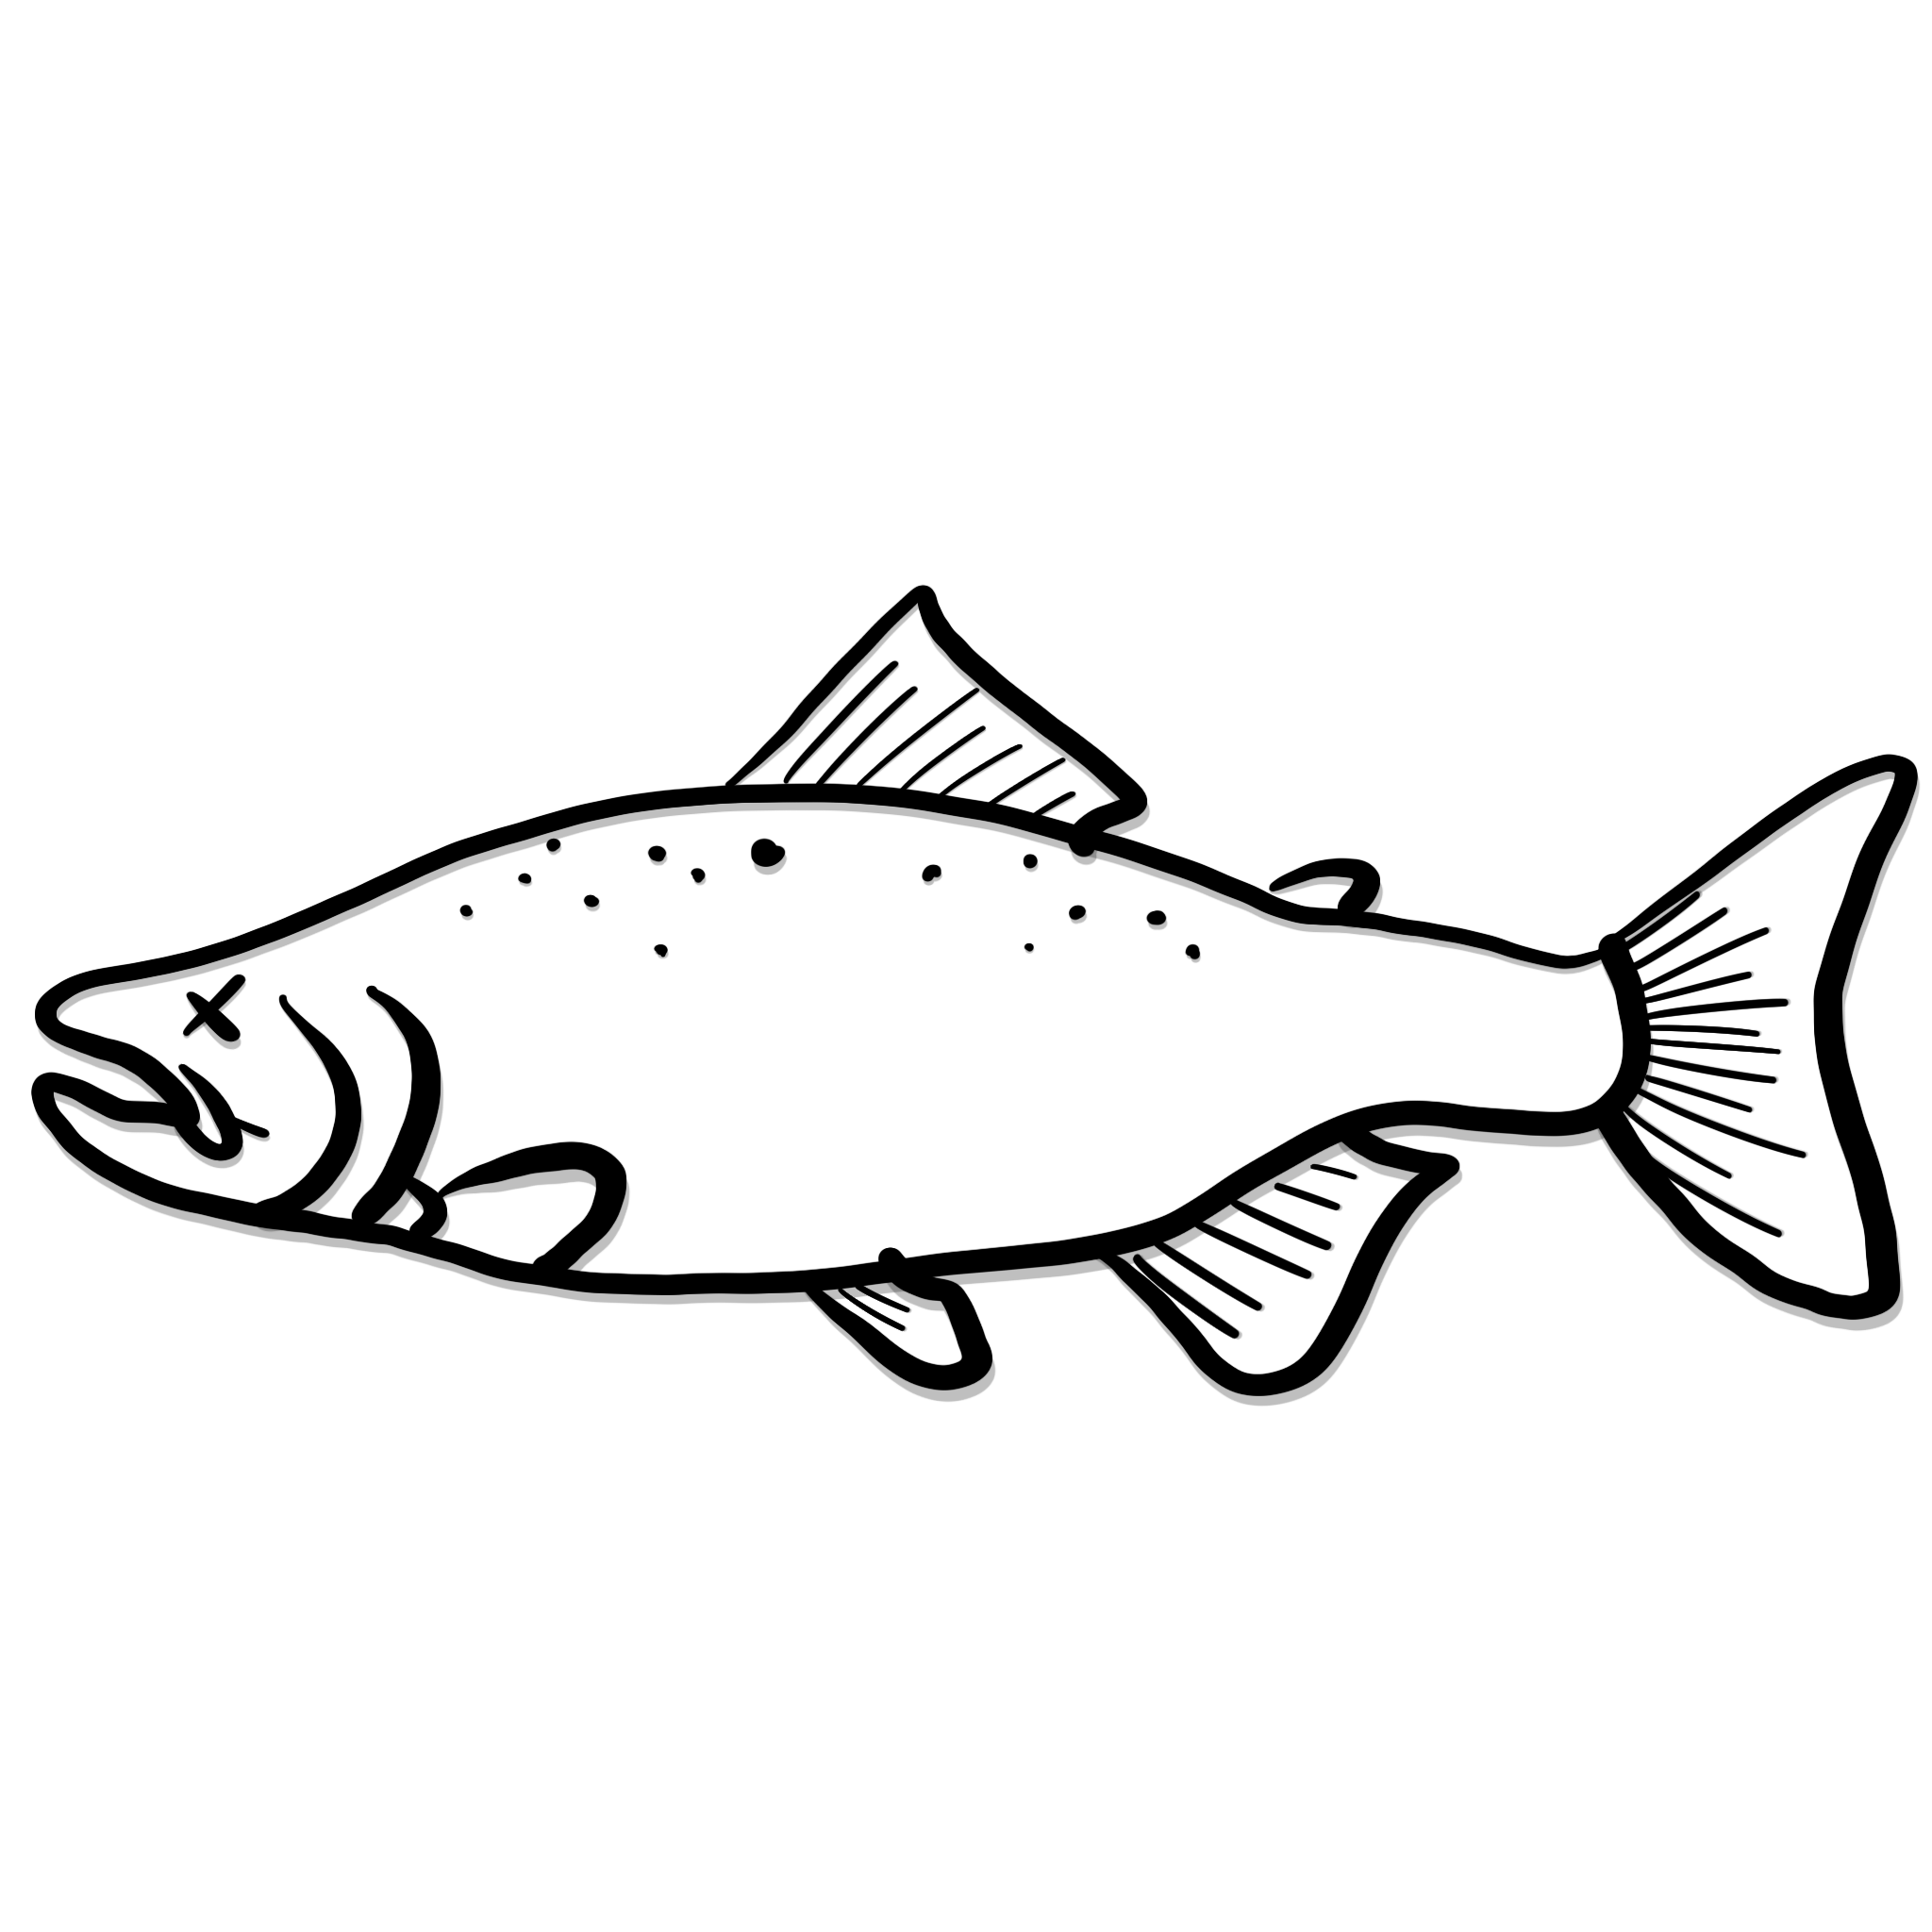

In [ ]:
#@title Dead Salmon


import base64

# Open the PNG image file in binary read mode
with open("salmon.png", "rb") as image_file:
    # Read the raw binary bytes and encode them into base64 bytes
    base64_bytes = base64.b64encode(image_file.read())

    # Decode the bytes into a readable UTF-8 string
    base64_string = base64_bytes.decode("utf-8")

SALMON_DATA_URI = "data:image/png;base64,"+base64_string


_salmon_html = mo.Html(f"""
<style>
.stinky-salmon {{
    position: relative;
    width: 240px;
    line-height: 0;
}}
.stinky-salmon .salmon-outline {{
    display: block;
    width: 100%;
    height: auto;
}}
.dark .stinky-salmon .salmon-outline {{
    filter: invert(1);
}}
.stinky-salmon .stink {{
    position: absolute;
    top: 0;
    left: 0;
    width: 100%;
    height: 100%;
    pointer-events: none;
    overflow: visible;
}}
.stink-line {{
    stroke: #6b8e3d;
    stroke-width: 2.5;
    fill: none;
    stroke-linecap: round;
    opacity: 0;
    animation: stink-rise 2.4s ease-out infinite;
    transform-box: fill-box;
    transform-origin: center;
}}
.dark .stink-line {{ stroke: #a8c97a; }}
.stink-text {{
    color: #6b8e3d;
    font-family: Georgia, 'Times New Roman', serif;
    font-weight: 700;
    animation: really-pulse 2.4s ease-in-out infinite;
}}
.dark .stink-text {{ color: #a8c97a; }}
@keyframes really-pulse {{
    0%, 100% {{ opacity: 0.55; }}
    50%      {{ opacity: 0.95; }}
}}
.stink-2 {{ animation-delay: 0.6s; }}
.stink-3 {{ animation-delay: 1.2s; }}
@keyframes stink-rise {{
    0%   {{ transform: translateY(36px); opacity: 0; }}
    25%  {{ opacity: 0.85; }}
    100% {{ transform: translateY(-36px); opacity: 0; }}
}}
</style>
<div class="stinky-salmon">
    <img class="salmon-outline"
         src="{SALMON_DATA_URI}"
         alt="Dead salmon outline (X eyes), with rising stink lines" />
    <svg class="stink" viewBox="0 0 320 320">
        <path class="stink-line stink-1"
              d="M 130 150 Q 138 140 130 130 T 130 110 T 130 90 T 130 70 T 130 50 T 130 30" />
        <path class="stink-line stink-2"
              d="M 160 140 Q 152 130 160 120 T 160 100 T 160 80 T 160 60 T 160 40 T 160 20" />
        <path class="stink-line stink-3"
              d="M 190 155 Q 198 145 190 135 T 190 115 T 190 95 T 190 75 T 190 55 T 190 35" />
    </svg>
</div>
""")

mo.vstack(
    [
        _salmon_html,

    ],
    align="center",
)

![](https://drive.google.com/uc?export=view&id=1xZptWGwrgJ1InjeZ4ckbVGgNPcBb-qnI)

[Dead Salmon Experiment](https://www.mathematik.uni-rostock.de/storages/uni-rostock/Alle_MNF/Mathematik/Struktur/Lehrstuehle/Analysis-Differentialgleichungen/salmon-fMRI.pdf)

A visual companion to "[The Dead Salmons of AI Interpretability](https://arxiv.org/abs/2512.18792)"
            (Méloux, Dirupo, Portet & Peyrard, 2025) — which revives the famous
            *dead-salmon fMRI* cautionary tale and argues that modern AI
            interpretability methods are vulnerable to the same class of
            statistical false-positive failures: feature attribution, probing,
            sparse autoencoders, concept directions and
            mechanistic circuit search can all produce confident-looking
            explanations for **randomly initialized models on random data**.

This notebook allows to *see* the failure modes the paper describes, not just read about them. Each section below rebuilds one of those traps as an interactive marimo demo: drag a slider, move a threshold, watch noise dress itself up as a finding. The voxel demo immediately below is the warm-up; the modern interpretability case studies start further down.

Move the sliders below to see how the false-positive rate and Bonferroni threshold change with the experiment shape.

### The gist, in plain English

Imagine **20,000 people** each flip a coin 200 times, and you look for
someone whose flips match a pattern you picked in advance. Even though
every coin is fair, with that many people you'll find **about 1,000**
whose flips "match" by pure luck.

That's what happens here — except the "people" are **voxels** (tiny 3D
pixels of a brain scan) and the "pattern" is a fake task. No voxel has
any real signal. But if you accept anything with "p < 0.05" as a
finding, you'll announce ~1,000 discoveries that are entirely noise.


**Multiple Testing Problem!**

The [Bonferroni correction](https://en.wikipedia.org/wiki/Bonferroni_correction) raises the bar: a finding only counts if
its p-value beats `0.05 / 20,000`. Apply it and the false alarms almost
entirely disappear.

In [ ]:
import math
from dataclasses import dataclass

import anywidget
import ipywidgets as widgets
import marimo as mo
import numpy as np
import traitlets
from vega_datasets import data

In [ ]:
def normal_cdf(x: np.ndarray) -> np.ndarray:
    """Approximate the standard normal CDF elementwise."""
    erf_vec = np.vectorize(math.erf)
    return 0.5 * (1.0 + erf_vec(x / math.sqrt(2.0)))

In [ ]:
#@title ExperimentResult
@dataclass
class ExperimentResult:
    """Container for the simulation outputs."""

    n_voxels: int
    alpha: float
    n_uncorrected_significant: int
    bonferroni_threshold: float
    n_bonferroni_significant: int
    p_values: np.ndarray
    correlations: np.ndarray


def simulate_false_positives(
    n_timepoints: int,
    n_voxels: int,
    alpha: float,
    seed: int,
) -> ExperimentResult:
    """Run voxel-wise tests on pure noise and count false positives."""
    rng = np.random.default_rng(seed)

    # Fake experimental regressor (e.g. "emotional vs non-emotional" blocks).
    task = rng.integers(0, 2, size=n_timepoints).astype(float)
    task = (task - task.mean()) / task.std(ddof=1)

    # Pure noise: no real signal in any voxel.
    noise = rng.normal(size=(n_timepoints, n_voxels))
    noise = (noise - noise.mean(axis=0)) / noise.std(axis=0, ddof=1)

    # Pearson correlation between each voxel and the fake task.
    correlations = (task[:, None] * noise).sum(axis=0) / (n_timepoints - 1)

    df = n_timepoints - 2
    t_stats = correlations * np.sqrt(
        df / np.maximum(1e-12, 1.0 - correlations**2)
    )
    p_values = 2.0 * (1.0 - normal_cdf(np.abs(t_stats)))

    n_uncorrected = int((p_values < alpha).sum())
    bonferroni_threshold = alpha / n_voxels
    n_bonferroni = int((p_values < bonferroni_threshold).sum())

    return ExperimentResult(
        n_voxels=n_voxels,
        alpha=alpha,
        n_uncorrected_significant=n_uncorrected,
        bonferroni_threshold=bonferroni_threshold,
        n_bonferroni_significant=n_bonferroni,
        p_values=p_values,
        correlations=correlations,
    )

In [ ]:
#@title False Positive Hunter
class FalsePositiveHunter(anywidget.AnyWidget):
    """Dual-view interactive hunter for the false-positive simulation.

    Drag the red line on the histogram to move the threshold; the voxel
    grid on the left repaints in real time. Buttons snap to the naive
    (alpha) or Bonferroni-corrected cutoff.
    """

    _esm = r"""
    function svgEl(tag, attrs) {
        const e = document.createElementNS("http://www.w3.org/2000/svg", tag);
        for (const k in attrs) e.setAttribute(k, attrs[k]);
        return e;
    }

    function render({ model, el }) {
        const wrapper = document.createElement("div");
        wrapper.style.cssText = `
            font-family: sans-serif;
            color: #222;
            background: #fafaf7;
            border: 1px solid #d8d8d0;
            border-radius: 8px;
            padding: 14px;
            display: flex;
            flex-direction: column;
            gap: 10px;
        `;

        const row = document.createElement("div");
        row.style.cssText = "display: flex; gap: 16px; align-items: flex-start; flex-wrap: wrap;";

        // --- Grid (canvas) ---
        const gridWrap = document.createElement("div");
        gridWrap.style.cssText = "display: flex; flex-direction: column; align-items: center; gap: 4px;";
        const gridTitle = document.createElement("div");
        gridTitle.style.cssText = "font-size: 12px; color: #333; font-weight: 500;";
        gridTitle.textContent = "Voxel grid — red = 'significant'";
        const CANVAS_SIZE = 320;
        const canvas = document.createElement("canvas");
        canvas.width = CANVAS_SIZE;
        canvas.height = CANVAS_SIZE;
        canvas.style.cssText = "border: 1px solid #ccc; border-radius: 4px; background: #f6f6f0; image-rendering: pixelated;";
        gridWrap.appendChild(gridTitle);
        gridWrap.appendChild(canvas);

        // --- Histogram (SVG) ---
        const HIST_W = 460, HIST_H = 340;
        const M = { l: 50, r: 15, t: 30, b: 40 };
        const PW = HIST_W - M.l - M.r;
        const PH = HIST_H - M.t - M.b;

        const svg = svgEl("svg", { width: HIST_W, height: HIST_H, viewBox: `0 0 ${HIST_W} ${HIST_H}` });
        svg.style.cssText = "border: 1px solid #ccc; border-radius: 4px; background: #fff; user-select: none; cursor: ew-resize;";

        const pToX = p => M.l + p * PW;
        const xToP = x => (x - M.l) / PW;

        const histTitle = svgEl("text", { x: HIST_W / 2, y: 18, "text-anchor": "middle", "font-size": 12, fill: "#333", "font-weight": 500 });
        histTitle.textContent = "P-value distribution — drag the red line";
        svg.appendChild(histTitle);

        svg.appendChild(svgEl("line", { x1: M.l, y1: M.t + PH, x2: M.l + PW, y2: M.t + PH, stroke: "#333" }));
        svg.appendChild(svgEl("line", { x1: M.l, y1: M.t, x2: M.l, y2: M.t + PH, stroke: "#333" }));

        for (let i = 0; i <= 10; i++) {
            const p = i / 10;
            const x = pToX(p);
            svg.appendChild(svgEl("line", { x1: x, y1: M.t + PH, x2: x, y2: M.t + PH + 4, stroke: "#333" }));
            const t = svgEl("text", { x, y: M.t + PH + 16, "text-anchor": "middle", "font-size": 10, fill: "#333" });
            t.textContent = p.toFixed(1);
            svg.appendChild(t);
        }
        const xlab = svgEl("text", { x: M.l + PW / 2, y: HIST_H - 8, "text-anchor": "middle", "font-size": 11, fill: "#333" });
        xlab.textContent = "p-value";
        svg.appendChild(xlab);
        const ylab = svgEl("text", {
            x: 14, y: M.t + PH / 2, "text-anchor": "middle", "font-size": 11, fill: "#333",
            transform: `rotate(-90 14 ${M.t + PH / 2})`,
        });
        ylab.textContent = "voxels";
        svg.appendChild(ylab);

        const barsGroup = svgEl("g", {});
        svg.appendChild(barsGroup);

        // Reference lines (no labels here — legend handles that)
        const alphaLine = svgEl("line", { y1: M.t, y2: M.t + PH, stroke: "#888", "stroke-dasharray": "3 3", "stroke-width": 1 });
        svg.appendChild(alphaLine);
        const bonfLine = svgEl("line", { y1: M.t, y2: M.t + PH, stroke: "#1a6b3a", "stroke-dasharray": "3 3", "stroke-width": 1 });
        svg.appendChild(bonfLine);

        // Legend in the top-right of the plot
        const legendGroup = svgEl("g", {});
        svg.appendChild(legendGroup);

        // Threshold handle (drawn last so it's on top)
        const thresholdLine = svgEl("line", { y1: M.t, y2: M.t + PH, stroke: "#c44", "stroke-width": 2, cursor: "ew-resize" });
        svg.appendChild(thresholdLine);
        const thresholdHandle = svgEl("rect", {
            y: M.t - 8, width: 14, height: 14, fill: "#c44",
            cursor: "ew-resize", rx: 3, stroke: "#fff", "stroke-width": 1.5,
        });
        svg.appendChild(thresholdHandle);

        row.appendChild(gridWrap);
        row.appendChild(svg);

        const readout = document.createElement("div");
        readout.style.cssText = "font-family: ui-monospace, monospace; font-size: 13px; line-height: 1.6; padding: 10px 12px; background: #fff; color: #222; border: 1px solid #e0e0d8; border-radius: 4px;";

        const buttons = document.createElement("div");
        buttons.style.cssText = "display: flex; gap: 8px; flex-wrap: wrap;";

        function makeBtn(label, bg, onClick) {
            const b = document.createElement("button");
            b.textContent = label;
            b.style.cssText = `padding: 6px 12px; border: 1px solid #888; background: ${bg}; color: #222; border-radius: 4px; cursor: pointer; font-size: 12px; font-family: sans-serif; font-weight: 500;`;
            b.onclick = onClick;
            return b;
        }
        buttons.appendChild(makeBtn("Naive: p < alpha", "#fff", () => {
            model.set("threshold", model.get("alpha"));
            model.save_changes();
        }));
        buttons.appendChild(makeBtn("Apply Bonferroni", "#d8f0d8", () => {
            model.set("threshold", model.get("bonferroni_threshold"));
            model.save_changes();
        }));

        wrapper.appendChild(row);
        wrapper.appendChild(readout);
        wrapper.appendChild(buttons);
        el.appendChild(wrapper);

        const c2d = canvas.getContext("2d");
        let binsCache = null;
        let binsMax = 1;

        function computeBins() {
            const pvals = model.get("p_values");
            const nBins = 50;
            const bins = new Array(nBins).fill(0);
            for (let i = 0; i < pvals.length; i++) {
                let bi = Math.floor(pvals[i] * nBins);
                if (bi >= nBins) bi = nBins - 1;
                if (bi < 0) bi = 0;
                bins[bi]++;
            }
            binsCache = bins;
            binsMax = 0;
            for (const v of bins) if (v > binsMax) binsMax = v;
            if (binsMax === 0) binsMax = 1;
        }

        function drawGrid() {
            const pvals = model.get("p_values");
            const n = pvals.length;
            const threshold = model.get("threshold");
            const side = Math.ceil(Math.sqrt(n));
            const cell = CANVAS_SIZE / side;
            c2d.fillStyle = "#f0f0e8";
            c2d.fillRect(0, 0, CANVAS_SIZE, CANVAS_SIZE);
            c2d.fillStyle = "#c44";
            const draw = Math.max(1, Math.ceil(cell));
            for (let i = 0; i < n; i++) {
                if (pvals[i] < threshold) {
                    const r = Math.floor(i / side);
                    const col = i % side;
                    c2d.fillRect(Math.floor(col * cell), Math.floor(r * cell), draw, draw);
                }
            }
        }

        function drawLegend() {
            while (legendGroup.firstChild) legendGroup.removeChild(legendGroup.firstChild);
            const alpha = model.get("alpha");
            const bonf = model.get("bonferroni_threshold");
            const lw = 150;
            const lh = 38;
            const lx = M.l + PW - lw - 6;
            const ly = M.t + 6;
            legendGroup.appendChild(svgEl("rect", {
                x: lx, y: ly, width: lw, height: lh,
                fill: "#fff", stroke: "#ccc", "stroke-width": 1, rx: 3, opacity: 0.96,
            }));
            // alpha
            legendGroup.appendChild(svgEl("line", {
                x1: lx + 8, y1: ly + 12, x2: lx + 26, y2: ly + 12,
                stroke: "#888", "stroke-dasharray": "3 2", "stroke-width": 1.5,
            }));
            const aT = svgEl("text", { x: lx + 32, y: ly + 15, "font-size": 11, fill: "#444" });
            aT.textContent = `alpha = ${alpha.toFixed(3)}`;
            legendGroup.appendChild(aT);
            // bonferroni
            legendGroup.appendChild(svgEl("line", {
                x1: lx + 8, y1: ly + 28, x2: lx + 26, y2: ly + 28,
                stroke: "#1a6b3a", "stroke-dasharray": "3 2", "stroke-width": 1.5,
            }));
            const bT = svgEl("text", { x: lx + 32, y: ly + 31, "font-size": 11, fill: "#1a6b3a" });
            bT.textContent = `Bonf = ${bonf.toExponential(1)}`;
            legendGroup.appendChild(bT);
        }

        function drawHist() {
            while (barsGroup.firstChild) barsGroup.removeChild(barsGroup.firstChild);
            if (!binsCache) computeBins();
            const bins = binsCache;
            const nBins = bins.length;
            const threshold = model.get("threshold");
            const binW = PW / nBins;
            for (let i = 0; i < nBins; i++) {
                const h = (bins[i] / binsMax) * PH;
                const x = M.l + i * binW;
                const y = M.t + PH - h;
                const binRight = (i + 1) / nBins;
                const flagged = binRight <= threshold + 1e-9;
                barsGroup.appendChild(svgEl("rect", {
                    x, y,
                    width: Math.max(0.5, binW - 0.5),
                    height: h,
                    fill: flagged ? "#c44" : "#aaa",
                    opacity: flagged ? 0.9 : 0.55,
                }));
            }

            const alpha = model.get("alpha");
            const bonf = model.get("bonferroni_threshold");

            const aX = pToX(Math.max(0, Math.min(1, alpha)));
            alphaLine.setAttribute("x1", aX);
            alphaLine.setAttribute("x2", aX);

            const bX = pToX(Math.max(0, Math.min(1, bonf)));
            bonfLine.setAttribute("x1", bX);
            bonfLine.setAttribute("x2", bX);

            const tX = pToX(Math.max(0, Math.min(1, threshold)));
            thresholdLine.setAttribute("x1", tX);
            thresholdLine.setAttribute("x2", tX);
            thresholdHandle.setAttribute("x", tX - 7);

            drawLegend();
        }

        function updateReadout() {
            const pvals = model.get("p_values");
            const n = pvals.length;
            const threshold = model.get("threshold");
            let count = 0;
            for (let i = 0; i < n; i++) if (pvals[i] < threshold) count++;
            const alpha = model.get("alpha");
            const bonf = model.get("bonferroni_threshold");
            const pct = (100 * count / n).toFixed(2);
            const expected = Math.round(alpha * n);

            let verdict;
            if (Math.abs(threshold - alpha) < alpha * 0.01) {
                verdict = `<b style="color:#c44">Naive threshold.</b> Pure noise produces ${count.toLocaleString()} 'discoveries' — close to alpha*N = ${expected.toLocaleString()}.`;
            } else if (Math.abs(threshold - bonf) < Math.max(bonf * 0.01, 1e-12)) {
                verdict = `<b style="color:#1a6b3a">Bonferroni threshold.</b> Only voxels with p &lt; 0.05/N pass. ${count.toLocaleString()} 'discoveries'.`;
            } else {
                verdict = `<span style="color:#555">Custom threshold.</span> ${count.toLocaleString()} 'discoveries' from pure noise.`;
            }

            const thrStr = threshold < 1e-3 ? threshold.toExponential(2) : threshold.toFixed(4);
            readout.innerHTML =
                `<span style="color:#555">Threshold:</span> <b>p &lt; ${thrStr}</b> &nbsp;·&nbsp; ` +
                `<span style="color:#555">Flagged:</span> <b>${count.toLocaleString()}</b> of ${n.toLocaleString()} (${pct}%)<br>` +
                verdict;
        }

        function redraw() { drawGrid(); drawHist(); updateReadout(); }

        let dragging = false;
        function ptX(evt) {
            const rect = svg.getBoundingClientRect();
            return (evt.clientX - rect.left) * (HIST_W / rect.width);
        }
        function setFromX(x) {
            let p = xToP(x);
            p = Math.max(1e-8, Math.min(1.0, p));
            model.set("threshold", p);
            model.save_changes();
        }
        svg.addEventListener("mousedown", (e) => { dragging = true; setFromX(ptX(e)); });
        window.addEventListener("mousemove", (e) => { if (dragging) setFromX(ptX(e)); });
        window.addEventListener("mouseup", () => { dragging = false; });

        model.on("change:threshold", redraw);
        model.on("change:p_values", () => { binsCache = null; redraw(); });
        model.on("change:alpha", redraw);
        model.on("change:bonferroni_threshold", redraw);

        redraw();
    }

    export default { render };
    """

    p_values = traitlets.List(trait=traitlets.Float()).tag(sync=True)
    alpha = traitlets.Float(0.05).tag(sync=True)
    bonferroni_threshold = traitlets.Float(2.5e-6).tag(sync=True)
    threshold = traitlets.Float(0.05).tag(sync=True)

In [ ]:
#@title False Positive Hunter Widget
n_timepoints = widgets.IntSlider(
    min=20, max=1000, step=10, value=500, description="n_timepoints",
    continuous_update=True
)

n_voxels = widgets.IntSlider(
    value=20_000, min=100, max=100_000, step=100, description="n_voxels",
    continuous_update=False
)
alpha = widgets.FloatSlider(
    value=0.05, min=0.001, max=0.2, step=0.001, description="alpha",
    readout_format=".3f", continuous_update=False
)
seed = widgets.BoundedIntText(value=42, min=0, max=10_000, step=1, description="seed")

display(widgets.VBox([n_timepoints, n_voxels, alpha, seed]))


result = simulate_false_positives(
    n_timepoints=n_timepoints.value,
    n_voxels=n_voxels.value,
    alpha=alpha.value,
    seed=int(seed.value),
)


hunter = mo.ui.anywidget(
    FalsePositiveHunter(
        p_values=result.p_values.tolist(),
        alpha=float(result.alpha),
        bonferroni_threshold=float(result.bonferroni_threshold),
        threshold=float(result.alpha),
    )
)
display(hunter)


# Bind sliders -> hunter widget
_updating = False

def refresh_hunter(*_):
    global _updating
    if _updating:
        return
    _updating = True

    try:
        r = simulate_false_positives(
            n_timepoints=n_timepoints.value,
            n_voxels=n_voxels.value,
            alpha=alpha.value,
            seed=int(seed.value),
        )

        # Batch updates to avoid extra renders
        with hunter.hold_sync():
            hunter.p_values = r.p_values.tolist()
            hunter.alpha = float(r.alpha)
            hunter.bonferroni_threshold = float(r.bonferroni_threshold)

            # optional: snap threshold to new alpha after recompute
            hunter.threshold = float(r.alpha)
    finally:
        _updating = False

# Observe value changes
for w in (n_timepoints, n_voxels, alpha, seed ):
  w.observe(refresh_hunter, names="value")

📝 **Note:** Bonferonni Correction is a rather conservative approach to address the multiple testing problem, and it reduces the power of the test. There are other "trade-off" approaches which control the false discovery rates.

---

### Does this happen with real data? Yes.

We just showed pure noise producing false positives. The math doesn't
care whether the "noise" is synthetic — any time you run many tests
with no real effect, ~alpha of them will flag as "significant".

Below we pull a classic **cars dataset** from `vega-datasets` and
p-hack it: split the cars into two groups by coin flip (no real
difference between groups), then run a t-test on every numeric
feature. Repeat many times. By design every test is null — yet ~5%
of them will come up "significant".

In [ ]:
n_splits = mo.ui.slider(
    start=50, stop=2000, step=50, value=500, label="random splits"
)
n_splits

slider()

In [ ]:
#@title P-hack Dataset

def _p_hack_dataset(df, n_splits, seed=1):
    """Coin-flip cars into two groups; Welch t-test each numeric feature.

    Returns p-values, raw effect sizes (mean_A - mean_B), and the feature
    tested for every (split, feature) pair — flattened in the same order.
    """
    rng = np.random.default_rng(seed)
    numeric = df.select_dtypes(include="number")
    X = numeric.to_numpy(dtype=float)
    X = X[~np.isnan(X).any(axis=1)]
    n = X.shape[0]
    feat_names = numeric.columns.tolist()

    p_chunks, e_chunks = [], []
    for _ in range(n_splits):
        group = rng.integers(0, 2, size=n).astype(bool)
        if not group.any() or group.all():
            continue
        a = X[group]
        b = X[~group]
        mean_diff = a.mean(axis=0) - b.mean(axis=0)
        se = np.sqrt(
            a.var(axis=0, ddof=1) / len(a) + b.var(axis=0, ddof=1) / len(b)
        )
        se = np.maximum(se, 1e-12)
        t = mean_diff / se
        p_chunks.append(2.0 * (1.0 - normal_cdf(np.abs(t))))
        e_chunks.append(mean_diff)

    return {
        "p_values": np.concatenate(p_chunks),
        "effect_sizes": np.concatenate(e_chunks),
        "features_per_test": feat_names * len(p_chunks),
        "feature_names": feat_names,
    }


cars_df = data.cars()
cars_phack = _p_hack_dataset(cars_df, n_splits.value)
cars_p_values = cars_phack["p_values"]
cars_features = cars_phack["feature_names"]
cars_total_tests = len(cars_p_values)
cars_alpha = 0.05
cars_bonf = cars_alpha / cars_total_tests

In [ ]:
mo.md(f"""
**Dataset:** `cars.json` — {len(cars_df):,} cars ·
features tested: {", ".join(f"`{c}`" for c in cars_features)}

**Tests run:** {n_splits.value:,} random splits × {len(cars_features)} features
= **{cars_total_tests:,}** t-tests, all null by construction.
""")

_md()

In [ ]:
#@title Car subgroup difference
cars_hunter = mo.ui.anywidget(
    FalsePositiveHunter(
        p_values=cars_p_values.tolist(),
        alpha=float(cars_alpha),
        bonferroni_threshold=float(cars_bonf),
        threshold=float(cars_alpha),
    )
)
cars_hunter

In [ ]:
#@title Car Paper
_threshold = cars_hunter.value["threshold"]
_p_vals = cars_phack["p_values"]
_effects = cars_phack["effect_sizes"]
_feats = cars_phack["features_per_test"]

_UNITS = {
    "Miles_per_Gallon": "mpg",
    "Cylinders": "cylinders",
    "Displacement": "cc displacement",
    "Horsepower": "hp",
    "Weight_in_lbs": "lbs",
    "Acceleration": "sec 0-60",
}

_passing = np.where(_p_vals < _threshold)[0]
_n_passing = int(len(_passing))

_items = []
if _n_passing > 0:
    _top = _passing[np.argsort(_p_vals[_passing])[:5]]
    for _i in _top:
        _feat = _feats[int(_i)]
        _eff = float(_effects[int(_i)])
        _p = float(_p_vals[int(_i)])
        _dir = "higher" if _eff > 0 else "lower"
        _unit = _UNITS.get(_feat, _feat)
        _p_str = f"{_p:.2e}" if _p < 1e-3 else f"{_p:.4f}"
        _items.append(
            "<li style='margin-bottom:6px;'>"
            f"Cohort A exhibited <b>{abs(_eff):.2f} {_unit}</b> {_dir} than Cohort B "
            f"(<i>p</i> = {_p_str}).</li>"
        )

_show_stink = _n_passing > 0 and _threshold > cars_bonf + 1e-10

_stink = (
    (
        """
<div style="
    position: absolute;
    top: 0;
    right: 20px;
    width: 220px;
    height: 240px;
    pointer-events: none;
    z-index: 2;
">
    <div class="stink-text" style="
        position: absolute;
        top: 6px;
        left: 24px;
        font-size: 38px;
        font-style: italic;
        transform: rotate(-6deg);
        pointer-events: none;
        z-index: 3;
    ">Really?</div>
    <svg viewBox="0 0 220 240" style="width: 100%; height: 100%; overflow: visible;">
        <path class="stink-line" style="animation-delay: 0s"   d="M 40 220 Q 50 205 40 190 T 40 160 T 40 130 T 40 100 T 40 70 T 40 40" />
        <path class="stink-line" style="animation-delay: 0.4s" d="M 90 220 Q 80 205 90 190 T 90 160 T 90 130 T 90 100 T 90 70 T 90 40" />
        <path class="stink-line" style="animation-delay: 0.8s" d="M 140 220 Q 150 205 140 190 T 140 160 T 140 130 T 140 100 T 140 70 T 140 40" />
        <path class="stink-line" style="animation-delay: 1.2s" d="M 180 220 Q 170 205 180 190 T 180 160 T 180 130 T 180 100 T 180 70 T 180 40" />
        <path class="stink-line" style="animation-delay: 1.6s" d="M 65 220 Q 75 205 65 190 T 65 160 T 65 130 T 65 100 T 65 70 T 65 40" />
    </svg>
</div>
"""
    )
    if _show_stink
    else ""
)

_results_list = (
    "<ul style='padding-left: 22px; margin: 0 0 14px 0;'>"
    + "".join(_items)
    + "</ul>"
    if _items
    else "<p style='color:#888; font-style:italic; margin: 0 0 14px 0;'>No findings at this threshold &mdash; there is no paper to publish.</p>"
)

_closing = (
    (
        "Our analysis reveals consistent and measurable differences between cohorts "
        "across multiple vehicle dimensions. We recommend manufacturer review and "
        "further investigation in light of these findings."
    )
    if _n_passing > 0
    else (
        "No effects were detected. The null hypothesis could not be rejected."
    )
)

_threshold_str = (
    f"{_threshold:.2e}" if _threshold < 1e-3 else f"{_threshold:.4f}"
)

mo.md(f"""
<div style="
    position: relative;
    max-width: 800px;
    margin: 20px auto;
    padding: 44px 56px 40px 56px;
    background: #fefef8;
    border: 1px solid #cac8c0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.18);
    font-family: Georgia, 'Times New Roman', serif;
    color: #222;
    line-height: 1.55;
    overflow: hidden;
">
    {_stink}
    <div style="text-align: center; border-bottom: 1px solid #888; padding-bottom: 14px; margin-bottom: 18px;">
        <div style="font-size: 10px; color: #666; letter-spacing: 2px; text-transform: uppercase;">
            Journal of Automotive Cohort Analysis &middot; Vol. 47 &middot; No. 3 &middot; pp. 412-418
        </div>
        <div style="font-size: 22px; margin: 10px 0 6px 0; line-height: 1.25; color: #111; font-weight: 700;">
            Systematic Variation Across Randomly Partitioned Automotive Cohorts
        </div>
        <div style="font-size: 15px; font-weight: 400; font-style: italic; color: #444; margin-bottom: 8px;">
            A Multi-Feature Analysis of {len(cars_df)} Vehicles
        </div>
        <div style="font-style: italic; color: #444; font-size: 13px;">
            M. Anon<sup>1</sup>, J. Hartman<sup>1</sup>, A. Claude<sup>2</sup>
        </div>
        <div style="font-size: 10px; color: #666; margin-top: 4px; letter-spacing: 0.5px;">
            <sup>1</sup>Institute for Premature Publication &middot; <sup>2</sup>Dept. of Exuberant Inference
        </div>
    </div>

    <div style="font-size: 13px;">
        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Abstract</div>
        <p style="text-align: justify; margin: 0 0 14px 0;">
            We analyzed <b>{len(cars_df)}</b> automobiles partitioned into two cohorts
            and conducted a systematic comparison across {len(cars_features)} mechanical
            and efficiency attributes. At a significance threshold of
            <i>p</i> &lt; {_threshold_str}, we identified
            <b>{_n_passing:,} statistically significant differences</b>.
            These results have implications for manufacturing specification,
            regulatory policy, and consumer guidance.
        </p>

        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Selected Results</div>
        {_results_list}

        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Conclusion</div>
        <p style="text-align: justify; margin: 0 0 14px 0;">
            {_closing}
        </p>

        <div style="font-size: 10px; color: #888; border-top: 1px dashed #bbb; padding-top: 10px; text-align: center; letter-spacing: 0.5px;">
            Manuscript generated from {cars_total_tests:,} null t-tests on vega-datasets/cars.json.
            Cohort assignment: uniformly random coin flip per vehicle.
        </div>
    </div>
</div>
""")

_md()

## ML/AI Interpretability: the same trap, in modern clothes

Everything above was classical statistics dressed for fMRI and for cars.
The same failure mode shows up across modern ML interpretability tools.
Below: three case studies where confident-looking explanations turn out
to be artifacts of high-dimensional noise, not of anything the model
actually learned or the data actually contains.

### Feature Attribution



Saliency maps, Grad-CAM, SHAP, Integrated Gradients — the promise is:
"here are the parts of the input the model cared about." [Adebayo et al.
(2018)](https://arxiv.org/abs/1810.03292) showed that many popular attribution methods produce **nearly
identical heatmaps even when you randomize the model's weights**. That
means the pretty overlay is mostly a projection of the input, not
evidence of what the model learned.

Below: we train a tiny linear classifier on synthetic 16×16 shapes
(circles vs squares), then compute input-times-gradient saliency for
both the trained weights and a fresh random model. The "hot" regions
line up on the shape in both cases — because `|W·x|` is near zero
wherever `x` is near zero, regardless of what `W` is.

In [ ]:
#@title Shape Dataset Generation and Fit
from sklearn.linear_model import LogisticRegression


def _make_shape_dataset(n_per_class=60, size=16, noise=0.12, seed=0):
    """Generate 16x16 grayscale shape images (0=disk, 1=square) with
    position jitter and Gaussian noise. Returns flat (n, size*size) array."""
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size]
    imgs, labels = [], []
    for lbl in (0, 1):
        for _ in range(n_per_class):
            img = rng.normal(0.0, noise, size=(size, size))
            cy = size // 2 + int(rng.integers(-2, 3))
            cx = size // 2 + int(rng.integers(-2, 3))
            r = 3
            if lbl == 0:
                mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r * r
            else:
                mask = (np.abs(yy - cy) <= r) & (np.abs(xx - cx) <= r)
            img = img + 0.9 * mask
            imgs.append(img.ravel())
            labels.append(lbl)
    X = np.array(imgs, dtype=float)
    y = np.array(labels, dtype=int)
    perm = rng.permutation(len(X))
    return X[perm], y[perm]


_attr_X, _attr_y = _make_shape_dataset(n_per_class=60, seed=0)
_attr_clf = LogisticRegression(max_iter=1000, C=10.0).fit(_attr_X, _attr_y)
attr_W = _attr_clf.coef_[0].astype(float)
attr_b = float(_attr_clf.intercept_[0])
attr_train_acc = float(_attr_clf.score(_attr_X, _attr_y))

attr_X_test, attr_y_test = _make_shape_dataset(n_per_class=10, seed=7)
attr_label_names = ["circle", "square"]

In [ ]:
#@title Attribution Code
class AttributionCompare(anywidget.AnyWidget):
    """Side-by-side saliency comparison: trained vs random model weights.

    The demo shows input-times-gradient saliency |W * x| for both a trained
    linear classifier and a fresh model with random weights of matching scale.
    Both maps light up the shape region — because |W * x| is near zero
    wherever x is near zero, regardless of W. The fingerprint of the input
    dominates the fingerprint of the model.
    """

    _esm = r"""
    function render({ model, el }) {
        const wrapper = document.createElement("div");
        wrapper.style.cssText = `
            font-family: sans-serif;
            color: #222;
            background: #fafaf7;
            border: 1px solid #d8d8d0;
            border-radius: 8px;
            padding: 14px;
            display: flex;
            flex-direction: column;
            gap: 12px;
        `;

        const row = document.createElement("div");
        row.style.cssText = "display: flex; gap: 14px; justify-content: center; flex-wrap: wrap;";

        const DISPLAY = 180;

        function makePanel(title) {
            const p = document.createElement("div");
            p.style.cssText = "display: flex; flex-direction: column; align-items: center; gap: 4px;";
            const t = document.createElement("div");
            t.style.cssText = "font-size: 12px; color: #333; font-weight: 500;";
            t.textContent = title;
            const c = document.createElement("canvas");
            c.width = DISPLAY;
            c.height = DISPLAY;
            c.style.cssText = "border: 1px solid #aaa; image-rendering: pixelated; background: #000;";
            p.appendChild(t);
            p.appendChild(c);
            return { panel: p, canvas: c, title: t };
        }

        const pInput = makePanel("Input image");
        const pTrained = makePanel("Saliency — trained model");
        const pRandom = makePanel("Saliency — random model");
        row.appendChild(pInput.panel);
        row.appendChild(pTrained.panel);
        row.appendChild(pRandom.panel);

        const controls = document.createElement("div");
        controls.style.cssText = "display: flex; gap: 10px; align-items: center; flex-wrap: wrap; justify-content: center;";

        function makeBtn(label, onClick) {
            const b = document.createElement("button");
            b.textContent = label;
            b.style.cssText = "padding: 6px 12px; border: 1px solid #888; background: #fff; color: #222; border-radius: 4px; cursor: pointer; font-size: 12px; font-family: sans-serif;";
            b.onclick = onClick;
            return b;
        }

        const idxLabel = document.createElement("span");
        idxLabel.style.cssText = "font-family: ui-monospace, monospace; font-size: 12px; color: #333; min-width: 110px; text-align: center;";

        controls.appendChild(makeBtn("Prev", () => {
            const n = model.get("n_test");
            let s = model.get("selected");
            s = (s - 1 + n) % n;
            model.set("selected", s);
            model.save_changes();
        }));
        controls.appendChild(idxLabel);
        controls.appendChild(makeBtn("Next", () => {
            const n = model.get("n_test");
            let s = model.get("selected");
            s = (s + 1) % n;
            model.set("selected", s);
            model.save_changes();
        }));
        controls.appendChild(makeBtn("Re-roll random model", () => {
            model.set("random_seed", model.get("random_seed") + 1);
            model.save_changes();
        }));

        const readout = document.createElement("div");
        readout.style.cssText = "font-family: ui-monospace, monospace; font-size: 13px; line-height: 1.55; padding: 10px 12px; background: #fff; color: #222; border: 1px solid #e0e0d8; border-radius: 4px;";

        wrapper.appendChild(row);
        wrapper.appendChild(controls);
        wrapper.appendChild(readout);
        el.appendChild(wrapper);

        function mulberry32(seed) {
            return function() {
                seed = (seed + 0x6D2B79F5) | 0;
                let t = seed;
                t = Math.imul(t ^ (t >>> 15), t | 1);
                t ^= t + Math.imul(t ^ (t >>> 7), t | 61);
                return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
            };
        }
        function randn(rng) {
            const u = 1 - rng();
            const v = rng();
            return Math.sqrt(-2 * Math.log(u)) * Math.cos(2 * Math.PI * v);
        }
        function stddev(arr) {
            let m = 0;
            for (const v of arr) m += v;
            m /= arr.length;
            let s = 0;
            for (const v of arr) s += (v - m) * (v - m);
            return Math.sqrt(s / arr.length);
        }
        function pearson(a, b) {
            const n = a.length;
            let sa=0, sb=0, saa=0, sbb=0, sab=0;
            for (let i = 0; i < n; i++) {
                sa += a[i]; sb += b[i];
                saa += a[i] * a[i]; sbb += b[i] * b[i];
                sab += a[i] * b[i];
            }
            const ma = sa / n, mb = sb / n;
            const cov = sab / n - ma * mb;
            const va = saa / n - ma * ma, vb = sbb / n - mb * mb;
            return cov / (Math.sqrt(va * vb) + 1e-12);
        }

        function grayscale(t) {
            t = Math.max(0, Math.min(1, t));
            const v = Math.floor(t * 255);
            return "rgb(" + v + "," + v + "," + v + ")";
        }
        function hot(t) {
            t = Math.max(0, Math.min(1, t));
            let r, g, b;
            if (t < 0.33) { r = Math.floor(t / 0.33 * 255); g = 0; b = 0; }
            else if (t < 0.67) { r = 255; g = Math.floor((t - 0.33) / 0.34 * 255); b = 0; }
            else { r = 255; g = 255; b = Math.floor((t - 0.67) / 0.33 * 255); }
            return "rgb(" + r + "," + g + "," + b + ")";
        }

        function drawImage(canvas, arr, colormap, clipPct) {
            const ctx = canvas.getContext("2d");
            const size = Math.round(Math.sqrt(arr.length));
            // robust normalization: clip top 2%
            const sorted = arr.slice().sort((a, b) => a - b);
            const mn = sorted[Math.floor(sorted.length * (clipPct || 0))];
            const mx = sorted[Math.floor(sorted.length * (1 - (clipPct || 0))) - 1];
            const range = Math.max(mx - mn, 1e-12);
            const px = canvas.width / size;
            for (let i = 0; i < size; i++) {
                for (let j = 0; j < size; j++) {
                    const val = (arr[i * size + j] - mn) / range;
                    ctx.fillStyle = colormap(val);
                    ctx.fillRect(Math.floor(j * px), Math.floor(i * px), Math.ceil(px), Math.ceil(px));
                }
            }
        }

        function refresh() {
            const images = model.get("images");
            const labels = model.get("labels");
            const Wt = model.get("W_trained");
            const size = model.get("image_size");
            const n = model.get("n_test");
            const names = model.get("label_names");
            const sel = model.get("selected");
            const seed = model.get("random_seed");

            const pixels = size * size;
            const img = images.slice(sel * pixels, (sel + 1) * pixels);

            const wStd = stddev(Wt);
            const rng = mulberry32(seed * 1337 + 42);
            const Wr = new Array(pixels);
            for (let i = 0; i < pixels; i++) Wr[i] = randn(rng) * wStd;

            const trainedSal = new Array(pixels);
            const randomSal = new Array(pixels);
            for (let i = 0; i < pixels; i++) {
                trainedSal[i] = Math.abs(Wt[i] * img[i]);
                randomSal[i] = Math.abs(Wr[i] * img[i]);
            }

            drawImage(pInput.canvas, img, grayscale, 0.02);
            drawImage(pTrained.canvas, trainedSal, hot, 0.02);
            drawImage(pRandom.canvas, randomSal, hot, 0.02);

            pInput.title.textContent = "Input: " + names[labels[sel]];
            idxLabel.textContent = "Image " + (sel + 1) + " of " + n;

            const r = pearson(trainedSal, randomSal);
            const rColor = r > 0.5 ? "#c44" : (r > 0.2 ? "#b80" : "#555");
            readout.innerHTML =
                "<b>Pearson r between trained and random saliency:</b> " +
                "<span style='color:" + rColor + "; font-weight:700;'>" + r.toFixed(3) + "</span><br>" +
                "<span style='color:#555;'>Both maps emphasize the shape region because " +
                "saliency = |W &middot; x| is near zero wherever x is near zero &mdash; " +
                "regardless of whether W came from training or from random noise.</span>";
        }

        model.on("change:selected", refresh);
        model.on("change:random_seed", refresh);
        refresh();
    }

    export default { render };
    """

    images = traitlets.List(trait=traitlets.Float()).tag(sync=True)
    labels = traitlets.List(trait=traitlets.Int()).tag(sync=True)
    W_trained = traitlets.List(trait=traitlets.Float()).tag(sync=True)
    image_size = traitlets.Int(16).tag(sync=True)
    n_test = traitlets.Int(0).tag(sync=True)
    label_names = traitlets.List(trait=traitlets.Unicode()).tag(sync=True)
    selected = traitlets.Int(0).tag(sync=True)
    random_seed = traitlets.Int(0).tag(sync=True)

In [ ]:
attr_widget = mo.ui.anywidget(
    AttributionCompare(
        images=attr_X_test.flatten().astype(float).tolist(),
        labels=attr_y_test.astype(int).tolist(),
        W_trained=attr_W.tolist(),
        image_size=16,
        n_test=int(len(attr_X_test)),
        label_names=attr_label_names,
    )
)
attr_widget

### Probing

![probing diagram](https://drive.google.com/thumbnail?id=1NlqHuIYpNXhd5roC45eCC6JLc-THlIFM&sz=w1000)

Probing classifiers are the "did the model encode X?" tool: train a
linear probe on a model's internal activations to decode some property,
and take success to mean the model "knows about" that property.

[Hewitt & Liang (2019)](https://arxiv.org/pdf/1909.03368) showed the trap: **a probe can succeed even when
the model is not using the decoded information for its output**. A
high-dimensional projection preserves almost everything fed into it — a
probe can recover a feature from the activations even if the downstream
readout completely ignores it.

Below: synthetic features flow through a fixed random hidden layer. A
linear readout is trained on `y = sin(1.5·x1) + noise` — only `x1`
matters. For every feature we measure:

- **Probe R²** — can a linear probe decode `xⱼ` from the hidden activations?
- **Ablation impact** — when we replace `xⱼ` with its mean, how much
  does the model's output change?

The probe says "yes, it's all in there!" The ablation says "no, only
`x1` is actually used." Both are true at the same time.

In [ ]:
probing_n_nuisance = mo.ui.slider(
    start=2, stop=20, step=1, value=5, label="nuisance features"
)
probing_n_nuisance

slider()

In [ ]:
#@title Probing Experiment
from sklearn.linear_model import Ridge


def _probing_experiment(n_samples=500, n_nuisance=5, hidden=32, seed=0):
    """Fixed random hidden layer + trained linear readout. Only x1 drives y.

    For each feature xj, computes: (a) the R² of a linear probe that
    decodes xj from the hidden activations, and (b) the RMS change in
    model output when xj is replaced by its mean.
    """
    rng = np.random.default_rng(seed)
    k = 1 + n_nuisance
    X = rng.normal(0, 1, size=(n_samples, k))
    y = np.sin(X[:, 0] * 1.5) + 0.1 * rng.normal(size=n_samples)

    W0 = rng.normal(0, 1 / np.sqrt(k), size=(k, hidden))
    b0 = rng.normal(0, 0.1, size=hidden)
    H = np.tanh(X @ W0 + b0)

    readout = Ridge(alpha=0.1).fit(H, y)
    y_pred = readout.predict(H)

    probe_r2 = []
    for j in range(k):
        p = Ridge(alpha=0.01).fit(H, X[:, j])
        probe_r2.append(float(max(0.0, p.score(H, X[:, j]))))

    abl_deltas = []
    for j in range(k):
        X_abl = X.copy()
        X_abl[:, j] = X[:, j].mean()
        H_abl = np.tanh(X_abl @ W0 + b0)
        y_abl = readout.predict(H_abl)
        abl_deltas.append(float(np.sqrt(np.mean((y_abl - y_pred) ** 2))))

    abl_arr = np.array(abl_deltas)
    abl_norm = (abl_arr / max(float(abl_arr.max()), 1e-12)).tolist()


    return {
        "feature_names": [f"x{j + 1}" for j in range(k)],
        "probe_r2": probe_r2,
        "ablation_impact": abl_norm,
        "ablation_raw": abl_deltas,
    }


probing_result = _probing_experiment(
    n_nuisance=probing_n_nuisance.value, seed=1
)




In [ ]:
#@title Probing Code
class ProbingCompare(anywidget.AnyWidget):
    """Grouped bar chart: per-feature probe R² vs ablation impact.

    Visualizes the Hewitt-Liang insight: probes can recover features the
    model does not actually use for its output.
    """

    _esm = r"""
    function svgEl(tag, attrs) {
        const e = document.createElementNS("http://www.w3.org/2000/svg", tag);
        for (const k in attrs) e.setAttribute(k, attrs[k]);
        return e;
    }

    function render({ model, el }) {
        const wrapper = document.createElement("div");
        wrapper.style.cssText = `
            font-family: sans-serif;
            color: #222;
            background: #fafaf7;
            border: 1px solid #d8d8d0;
            border-radius: 8px;
            padding: 14px;
            display: flex;
            flex-direction: column;
            gap: 10px;
        `;

        const W = 640, H = 340;
        const M = { l: 50, r: 15, t: 50, b: 42 };
        const PW = W - M.l - M.r;
        const PH = H - M.t - M.b;

        const svg = svgEl("svg", { width: W, height: H, viewBox: "0 0 " + W + " " + H });
        svg.style.cssText = "background: #fff; border: 1px solid #ccc; border-radius: 4px; user-select: none;";

        const title = svgEl("text", {
            x: W / 2, y: 20, "text-anchor": "middle",
            "font-size": 13, "font-weight": 600, fill: "#333",
        });
        title.textContent = "Probe-decodability vs ablation-impact, per feature";
        svg.appendChild(title);

        const legend = svgEl("g", {});
        legend.appendChild(svgEl("rect", { x: 70, y: 30, width: 14, height: 10, fill: "#3a77bf" }));
        const l1 = svgEl("text", { x: 90, y: 39, "font-size": 11, fill: "#333" });
        l1.textContent = "Probe R² (linear decode from hidden)";
        legend.appendChild(l1);
        legend.appendChild(svgEl("rect", { x: 360, y: 30, width: 14, height: 10, fill: "#c44" }));
        const l2 = svgEl("text", { x: 380, y: 39, "font-size": 11, fill: "#333" });
        l2.textContent = "Ablation impact on output (normalized)";
        legend.appendChild(l2);
        svg.appendChild(legend);

        svg.appendChild(svgEl("line", { x1: M.l, y1: M.t, x2: M.l, y2: M.t + PH, stroke: "#333" }));
        for (let i = 0; i <= 4; i++) {
            const yv = i / 4;
            const py = M.t + PH - yv * PH;
            svg.appendChild(svgEl("line", { x1: M.l - 4, y1: py, x2: M.l, y2: py, stroke: "#333" }));
            const tk = svgEl("text", {
                x: M.l - 6, y: py + 3, "font-size": 10, fill: "#555", "text-anchor": "end",
            });
            tk.textContent = yv.toFixed(2);
            svg.appendChild(tk);
        }
        const ylab = svgEl("text", {
            x: 14, y: M.t + PH / 2, "text-anchor": "middle", "font-size": 11, fill: "#333",
            transform: "rotate(-90 14 " + (M.t + PH / 2) + ")",
        });
        ylab.textContent = "score";
        svg.appendChild(ylab);

        svg.appendChild(svgEl("line", { x1: M.l, y1: M.t + PH, x2: M.l + PW, y2: M.t + PH, stroke: "#333" }));

        const barsGroup = svgEl("g", {});
        svg.appendChild(barsGroup);

        const readout = document.createElement("div");
        readout.style.cssText = "font-family: ui-monospace, monospace; font-size: 13px; line-height: 1.55; padding: 10px 12px; background: #fff; color: #222; border: 1px solid #e0e0d8; border-radius: 4px;";

        wrapper.appendChild(svg);
        wrapper.appendChild(readout);
        el.appendChild(wrapper);

        function redraw() {
            while (barsGroup.firstChild) barsGroup.removeChild(barsGroup.firstChild);
            const features = model.get("feature_names");
            const probes = model.get("probe_r2");
            const ablations = model.get("ablation_impact");
            const k = features.length;
            if (k === 0) return;
            const slot = PW / k;
            const barW = Math.min(24, slot * 0.35);

            for (let i = 0; i < k; i++) {
                const cx = M.l + i * slot + slot / 2;
                const probeH = Math.max(0, Math.min(1, probes[i])) * PH;
                barsGroup.appendChild(svgEl("rect", {
                    x: cx - barW - 2, y: M.t + PH - probeH,
                    width: barW, height: probeH,
                    fill: "#3a77bf", opacity: 0.85,
                }));
                const ablH = Math.max(0, Math.min(1, ablations[i])) * PH;
                barsGroup.appendChild(svgEl("rect", {
                    x: cx + 2, y: M.t + PH - ablH,
                    width: barW, height: ablH,
                    fill: "#c44", opacity: 0.85,
                }));
                const lbl = svgEl("text", {
                    x: cx, y: M.t + PH + 16, "text-anchor": "middle",
                    "font-size": 11, fill: "#333",
                    "font-weight": i === 0 ? 700 : 400,
                });
                lbl.textContent = features[i];
                barsGroup.appendChild(lbl);
            }

            const nProbeHigh = probes.filter(function(r) { return r > 0.5; }).length;
            const nAblHigh = ablations.filter(function(a) { return a > 0.25; }).length;
            readout.innerHTML =
                "Probes can decode <b style='color:#3a77bf'>" + nProbeHigh + " of " + k +
                " features</b> from the hidden activations. " +
                "Ablating features changes the model's output for only " +
                "<b style='color:#c44'>" + nAblHigh + " of " + k + "</b>.<br>" +
                "<span style='color:#555'>The representation <i>contains</i> the nuisance features; " +
                "the output does not <i>use</i> them. A successful probe is not evidence " +
                "that the model relies on the decoded feature.</span>";
        }

        model.on("change:probe_r2", redraw);
        model.on("change:ablation_impact", redraw);
        model.on("change:feature_names", redraw);
        redraw();
    }

    export default { render };
    """

    feature_names = traitlets.List(trait=traitlets.Unicode()).tag(sync=True)
    probe_r2 = traitlets.List(trait=traitlets.Float()).tag(sync=True)
    ablation_impact = traitlets.List(trait=traitlets.Float()).tag(sync=True)

In [ ]:
probing_n_nuisance = mo.ui.slider(
    start=2, stop=20, step=1, value=5, label="nuisance features"
)
probing_n_nuisance

slider()

In [ ]:



probing_result = _probing_experiment(
    n_nuisance=probing_n_nuisance.value, seed=1
)


probing_widget = mo.ui.anywidget(
    ProbingCompare(
        feature_names=probing_result["feature_names"],
        probe_r2=probing_result["probe_r2"],
        ablation_impact=probing_result["ablation_impact"],
    )
)
probing_widget

### Sparse Autoencoders



![sparse autoencoder](https://drive.google.com/uc?exporthttps://drive.google.com/uc?export=view&id=1rIeUhIBtb-CmQAz54FOknNGqVxhlxjMP)

Sparse autoencoders fit on the model's activations with an L1 penalty produce a dictionary of features deemed to be "interpretable" ([Cunningham et al., 2023](https://arxiv.org/pdf/2309.08600)). Each feature is
then hand-labeled ("this one fires on Arabic script", "this one on car
windshields") and taken as evidence of the model's internal conceptual
vocabulary. However, [Heap et al., 2025]() showed that a SAEs can recover "interpretable" components even in randomly initialied transformers.

Fit the same optimizer to **pure Gaussian noise** and you still get a
dictionary of crisp, human-nameable "features." Below: 2000 random 8×8
noise patches → `MiniBatchDictionaryLearning` with 32 atoms. Each tile
in the gallery is one learned atom. Several will look spatially
localized, oriented, blob- or edge-resembling — all the properties a
real SAE atom would have. The structure is in the optimizer, not the
data.

In [ ]:
#@title Fitting SAE
from sklearn.decomposition import MiniBatchDictionaryLearning


def _fit_sae_to_noise(n_samples=2000, patch_size=8, n_atoms=32, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n_samples, patch_size * patch_size))
    X = X - X.mean(axis=1, keepdims=True)
    dl = MiniBatchDictionaryLearning(
        n_components=n_atoms,
        alpha=1.0,
        batch_size=64,
        max_iter=200,
        transform_algorithm="lasso_lars",
        random_state=seed,
    )
    dl.fit(X)
    return {
        "atoms": dl.components_.astype(float),
        "patch_size": patch_size,
        "n_atoms": n_atoms,
    }


sae_result = _fit_sae_to_noise(seed=0)

In [ ]:
#@title Sparse Feature Code
class SparseFeatureGallery(anywidget.AnyWidget):
    """Render a grid of dictionary atoms as tiny diverging-colormap tiles.

    Pedagogical demo: an SAE fit to pure Gaussian noise still produces
    spatially-localized, feature-looking atoms. The structure is in the
    optimizer, not the data.
    """

    _esm = r"""
    function render({ model, el }) {
        const wrapper = document.createElement("div");
        wrapper.style.cssText = `
            font-family: sans-serif;
            color: #222;
            background: #fafaf7;
            border: 1px solid #d8d8d0;
            border-radius: 8px;
            padding: 14px;
            display: flex;
            flex-direction: column;
            gap: 12px;
        `;

        const title = document.createElement("div");
        title.style.cssText = "font-size: 12px; color: #333; font-weight: 600; letter-spacing: 0.5px;";
        title.textContent = "Learned dictionary — 32 atoms, fit to 2000 patches of pure Gaussian noise";
        wrapper.appendChild(title);

        const grid = document.createElement("div");
        const cols = 8;
        const tileSize = 72;
        grid.style.cssText =
            "display: grid; " +
            "grid-template-columns: repeat(" + cols + ", " + tileSize + "px); " +
            "gap: 8px; " +
            "justify-content: center;";
        wrapper.appendChild(grid);

        const footer = document.createElement("div");
        footer.style.cssText = "font-family: ui-monospace, monospace; font-size: 13px; line-height: 1.55; padding: 10px 12px; background: #fff; color: #222; border: 1px solid #e0e0d8; border-radius: 4px;";
        wrapper.appendChild(footer);

        el.appendChild(wrapper);

        function diverging(val, maxabs) {
            const t = val / (maxabs + 1e-12);
            if (t >= 0) {
                const k = Math.min(1, t);
                const c = Math.floor((1 - k) * 255);
                return "rgb(255," + c + "," + c + ")";
            } else {
                const k = Math.min(1, -t);
                const c = Math.floor((1 - k) * 255);
                return "rgb(" + c + "," + c + ",255)";
            }
        }

        function redraw() {
            while (grid.firstChild) grid.removeChild(grid.firstChild);
            const atoms = model.get("atoms");
            const patchSize = model.get("patch_size");
            const nAtoms = model.get("n_atoms");
            const pxs = patchSize * patchSize;

            for (let i = 0; i < nAtoms; i++) {
                const atom = atoms.slice(i * pxs, (i + 1) * pxs);
                let mx = 0;
                for (const v of atom) { const a = Math.abs(v); if (a > mx) mx = a; }

                const cell = document.createElement("div");
                cell.style.cssText = "display: flex; flex-direction: column; align-items: center; gap: 2px;";

                const canvas = document.createElement("canvas");
                canvas.width = tileSize;
                canvas.height = tileSize;
                canvas.style.cssText = "border: 1px solid #bbb; image-rendering: pixelated; background: #fff;";
                const ctx = canvas.getContext("2d");
                const px = tileSize / patchSize;
                for (let r = 0; r < patchSize; r++) {
                    for (let c = 0; c < patchSize; c++) {
                        ctx.fillStyle = diverging(atom[r * patchSize + c], mx);
                        ctx.fillRect(Math.floor(c * px), Math.floor(r * px), Math.ceil(px), Math.ceil(px));
                    }
                }

                const label = document.createElement("div");
                label.style.cssText = "font-size: 10px; color: #555; font-family: ui-monospace, monospace;";
                label.textContent = "#" + (i + 1);

                cell.appendChild(canvas);
                cell.appendChild(label);
                grid.appendChild(cell);
            }

            footer.innerHTML =
                "<b>All 32 atoms above were fit to 2000 patches of pure Gaussian noise.</b> " +
                "No underlying structure. If several of them look like \"features\" &mdash; a blob here, " +
                "an oriented edge there, a localized cluster of positive or negative weight &mdash; " +
                "that's the pedagogical point. Sparse dictionary learning produces feature-looking atoms " +
                "by construction; the L1 objective <i>makes</i> them localized regardless of what's in the data. " +
                "A real SAE fit to a model's activations would look indistinguishable from this.";
        }

        model.on("change:atoms", redraw);
        model.on("change:n_atoms", redraw);
        redraw();
    }

    export default { render };
    """

    atoms = traitlets.List(trait=traitlets.Float()).tag(sync=True)
    patch_size = traitlets.Int(8).tag(sync=True)
    n_atoms = traitlets.Int(32).tag(sync=True)

In [ ]:
sae_widget = mo.ui.anywidget(
    SparseFeatureGallery(
        atoms=sae_result["atoms"].flatten().tolist(),
        patch_size=sae_result["patch_size"],
        n_atoms=sae_result["n_atoms"],
    )
)
sae_widget

### Concept-Based Explanations



TCAV (Kim et al. 2018) and its descendants frame interpretability as
*"we found a direction in activation space aligned with a human concept,
and the model is sensitive to that direction — therefore the model uses
that concept."* In high-dimensional activation spaces, the trap is the
same one we've seen all along: **any random direction, out of enough
random directions, will appear "significantly" aligned with the model's
output**.

Below: we treat the Phase-1 shape classifier's weight vector `attr_W`
as the "model's decision direction" in 256-dim input/activation space,
then generate `N` random unit-vector "concepts" and compute each
concept's cosine similarity with the model's decision direction.
Under the null (random concepts), cosine similarity is approximately
`N(0, 1/256)` — we z-score and two-sided-test each concept, then feed
the p-values into the same hunter widget. Naive `p < 0.05` produces
~5% of concepts looking "significant."

In [ ]:
n_concepts_slider = mo.ui.slider(
    start=50, stop=1000, step=50, value=500, label="random concept directions"
)
n_concepts_slider

slider()

In [ ]:
#@title Concept Experiment
def _concept_experiment(n_concepts=500, W=None, seed=0):
    """Random unit-vector concepts; cosine similarity with W as TCAV proxy.

    Under the null, a uniformly random unit vector c in d-dim space has
    c . W_unit ~ approximately N(0, 1/d). We use this to get analytic
    p-values for each concept.
    """
    rng = np.random.default_rng(seed)
    W_unit = W / np.maximum(np.linalg.norm(W), 1e-12)
    dim = W.shape[0]
    C = rng.normal(0, 1, size=(n_concepts, dim))
    C = C / np.maximum(np.linalg.norm(C, axis=1, keepdims=True), 1e-12)
    cos = C @ W_unit
    z = cos * np.sqrt(dim)
    p_values = 2.0 * (1.0 - normal_cdf(np.abs(z)))
    return {
        "p_values": p_values,
        "cosines": cos,
        "n_concepts": n_concepts,
    }


concept_result = _concept_experiment(
    n_concepts=n_concepts_slider.value, W=attr_W, seed=1
)
concept_alpha = 0.05
concept_bonf = concept_alpha / max(concept_result["n_concepts"], 1)

In [ ]:
concept_hunter = mo.ui.anywidget(
    FalsePositiveHunter(
        p_values=concept_result["p_values"].tolist(),
        alpha=float(concept_alpha),
        bonferroni_threshold=float(concept_bonf),
        threshold=float(concept_alpha),
    )
)
concept_hunter

In [ ]:
#@title Concept Hunter Paper
_threshold = concept_hunter.value["threshold"]
_p_vals = concept_result["p_values"]
_cos = concept_result["cosines"]
_n_total = concept_result["n_concepts"]

_passing = np.where(_p_vals < _threshold)[0]
_n_passing = int(len(_passing))

_items = []
if _n_passing > 0:
    _top = _passing[np.argsort(_p_vals[_passing])[:5]]
    for _k in _top:
        _idx = int(_k)
        _c = float(_cos[_idx])
        _p = float(_p_vals[_idx])
        _p_str = f"{_p:.2e}" if _p < 1e-3 else f"{_p:.4f}"
        _sign = "+" if _c >= 0 else "-"
        _items.append(
            "<li style='margin-bottom:6px;'>"
            f"<b>Concept #{_idx + 1:03d}</b>: cosine alignment with decision direction "
            f"= {_sign}{abs(_c):.3f} (<i>p</i> = {_p_str}). A "
            f"statistically significant conceptual axis.</li>"
        )

_show_stink = _n_passing > 0 and _threshold > concept_bonf + 1e-10

_stink = (
    (
        """
<div style="
    position: absolute;
    top: 0;
    right: 20px;
    width: 220px;
    height: 240px;
    pointer-events: none;
    z-index: 2;
">
    <div class="stink-text" style="
        position: absolute;
        top: 6px;
        left: 24px;
        font-size: 38px;
        font-style: italic;
        transform: rotate(-6deg);
        pointer-events: none;
        z-index: 3;
    ">Really?</div>
    <svg viewBox="0 0 220 240" style="width: 100%; height: 100%; overflow: visible;">
        <path class="stink-line" style="animation-delay: 0s"   d="M 40 220 Q 50 205 40 190 T 40 160 T 40 130 T 40 100 T 40 70 T 40 40" />
        <path class="stink-line" style="animation-delay: 0.4s" d="M 90 220 Q 80 205 90 190 T 90 160 T 90 130 T 90 100 T 90 70 T 90 40" />
        <path class="stink-line" style="animation-delay: 0.8s" d="M 140 220 Q 150 205 140 190 T 140 160 T 140 130 T 140 100 T 140 70 T 140 40" />
        <path class="stink-line" style="animation-delay: 1.2s" d="M 180 220 Q 170 205 180 190 T 180 160 T 180 130 T 180 100 T 180 70 T 180 40" />
        <path class="stink-line" style="animation-delay: 1.6s" d="M 65 220 Q 75 205 65 190 T 65 160 T 65 130 T 65 100 T 65 70 T 65 40" />
    </svg>
</div>
"""
    )
    if _show_stink
    else ""
)

_items_html = (
    "<ul style='padding-left: 22px; margin: 0 0 14px 0;'>"
    + "".join(_items)
    + "</ul>"
    if _items
    else "<p style='color:#888; font-style:italic; margin: 0 0 14px 0;'>No conceptual axes survive this threshold.</p>"
)

_closing = (
    (
        "Our analysis reveals that the classifier has learned a rich and "
        "interpretable conceptual vocabulary. Several of the discovered axes "
        "merit follow-up qualitative investigation with domain experts."
    )
    if _n_passing > 0
    else (
        "No concept directions were found to be statistically aligned with the "
        "classifier's decision surface."
    )
)

_threshold_str = (
    f"{_threshold:.2e}" if _threshold < 1e-3 else f"{_threshold:.4f}"
)

mo.md(f"""
<div style="
    position: relative;
    max-width: 800px;
    margin: 20px auto;
    padding: 44px 56px 40px 56px;
    background: #fefef8;
    border: 1px solid #cac8c0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.18);
    font-family: Georgia, 'Times New Roman', serif;
    color: #222;
    line-height: 1.55;
    overflow: hidden;
">
    {_stink}
    <div style="text-align: center; border-bottom: 1px solid #888; padding-bottom: 14px; margin-bottom: 18px;">
        <div style="font-size: 10px; color: #666; letter-spacing: 2px; text-transform: uppercase;">
            Annals of Interpretable Attribution &middot; Vol. 22 &middot; No. 4 &middot; pp. 208-219
        </div>
        <div style="font-size: 22px; margin: 10px 0 6px 0; line-height: 1.25; color: #111; font-weight: 700;">
            Learned Conceptual Vocabulary of a Shape Classifier
        </div>
        <div style="font-size: 15px; font-weight: 400; font-style: italic; color: #444; margin-bottom: 8px;">
            A TCAV-Style Investigation of Decision-Aligned Directions
        </div>
        <div style="font-style: italic; color: #444; font-size: 13px;">
            A. Plaus<sup>1</sup>, Q. Sensible<sup>1</sup>, E. Vidence<sup>2</sup>
        </div>
        <div style="font-size: 10px; color: #666; margin-top: 4px; letter-spacing: 0.5px;">
            <sup>1</sup>Concept Attribution Lab &middot; <sup>2</sup>Center for Confident Interpretation
        </div>
    </div>

    <div style="font-size: 13px;">
        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Abstract</div>
        <p style="text-align: justify; margin: 0 0 14px 0;">
            Across a survey of <b>{_n_total:,}</b> candidate concept directions in the 256-dimensional
            activation space of a shape classifier, we identify <b>{_n_passing:,} directions
            statistically aligned</b> with the model's decision surface at significance threshold
            <i>p</i> &lt; {_threshold_str}. These axes constitute an interpretable conceptual vocabulary
            the model uses to make its classification decisions.
        </p>

        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Selected Conceptual Axes</div>
        {_items_html}

        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Conclusion</div>
        <p style="text-align: justify; margin: 0 0 14px 0;">
            {_closing}
        </p>

        <div style="font-size: 10px; color: #888; border-top: 1px dashed #bbb; padding-top: 10px; text-align: center; letter-spacing: 0.5px;">
            Manuscript generated from {_n_total:,} cosine-similarity tests between uniformly-random
            unit vectors and the classifier weight vector. The "concepts" are pure random directions.
        </div>
    </div>
</div>
""")

_md()

### Mechanistic Interpretability


The deepest corner of the interpretability tree: find *circuits* — small
subsets of neurons that implement a specific model behavior. At small
scale, with cherry-picked examples, this can be genuinely illuminating.
At scale, with automated search across many candidate circuits and many
candidate behaviors, it runs straight into the same wall: **brute-force
search across enough noisy candidates will "discover" circuits that
look convincingly specialized for any target behavior you pick, even
when the neurons are random and the behavior is a coin flip**.

Below: we define a "target behavior" by flipping a coin for each of 400
random input vectors — so the labels have no underlying relationship to
the inputs at all. We then search through `N` candidate two-neuron
"circuits" (random weight matrices feeding a random linear readout) and
two-sample t-test each circuit's output across the random labels.
Feed the per-circuit p-values into the hunter widget; the naive
threshold announces dozens of "discovered circuits" for a behavior
that doesn't exist.

In [ ]:
n_circuits_slider = mo.ui.slider(
    start=100,
    stop=2000,
    step=100,
    value=500,
    label="candidate circuits searched",
)
n_circuits_slider

slider()

In [ ]:
#@title Circuit Experiment
def _circuit_experiment(n_circuits=500, n_samples=400, input_dim=64, seed=0):
    """Brute-force search over random 2-neuron circuits for a target behavior
    defined by random coin-flip labels.

    Under the null (random labels), t-tests yield uniform p-values and
    ~alpha of the circuits will appear "selective" by chance.
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n_samples, input_dim))
    labels = rng.integers(0, 2, size=n_samples).astype(bool)
    n_a = int(labels.sum())
    n_b = n_samples - n_a

    p_values = np.empty(n_circuits)
    effect_sizes = np.empty(n_circuits)
    for c in range(n_circuits):
        W = rng.normal(0, 1 / np.sqrt(input_dim), size=(2, input_dim))
        v = rng.normal(0, 1, size=2)
        out = np.tanh(X @ W.T) @ v
        a = out[labels]
        b = out[~labels]
        mean_diff = float(a.mean() - b.mean())
        se = float(np.sqrt(a.var(ddof=1) / n_a + b.var(ddof=1) / n_b))
        t = mean_diff / max(se, 1e-12)
        p_values[c] = float(2.0 * (1.0 - normal_cdf(np.abs(t))))
        effect_sizes[c] = mean_diff
    return {
        "p_values": p_values,
        "effect_sizes": effect_sizes,
        "n_circuits": n_circuits,
        "n_samples": n_samples,
    }


circuit_result = _circuit_experiment(
    n_circuits=n_circuits_slider.value, seed=2
)
circuit_alpha = 0.05
circuit_bonf = circuit_alpha / max(circuit_result["n_circuits"], 1)

In [ ]:
circuit_hunter = mo.ui.anywidget(
    FalsePositiveHunter(
        p_values=circuit_result["p_values"].tolist(),
        alpha=float(circuit_alpha),
        bonferroni_threshold=float(circuit_bonf),
        threshold=float(circuit_alpha),
    )
)
circuit_hunter

In [ ]:
#@title Circuit Hunter Paper
_threshold = circuit_hunter.value["threshold"]
_p_vals = circuit_result["p_values"]
_effects = circuit_result["effect_sizes"]
_n_total = circuit_result["n_circuits"]

_passing = np.where(_p_vals < _threshold)[0]
_n_passing = int(len(_passing))

_items = []
if _n_passing > 0:
    _top = _passing[np.argsort(_p_vals[_passing])[:5]]
    for _k in _top:
        _idx = int(_k)
        _eff = float(_effects[_idx])
        _p = float(_p_vals[_idx])
        _p_str = f"{_p:.2e}" if _p < 1e-3 else f"{_p:.4f}"
        _sign = "+" if _eff >= 0 else "-"
        _items.append(
            "<li style='margin-bottom:6px;'>"
            f"<b>Circuit #{_idx + 1:03d}</b>: mean output difference "
            f"{_sign}{abs(_eff):.3f} between target-behavior and control inputs "
            f"(t-test <i>p</i> = {_p_str}). A two-neuron subgraph reliably "
            f"discriminating the target behavior.</li>"
        )

_show_stink = _n_passing > 0 and _threshold > circuit_bonf + 1e-10

_stink = (
    (
        """
<div style="
    position: absolute;
    top: 0;
    right: 20px;
    width: 220px;
    height: 240px;
    pointer-events: none;
    z-index: 2;
">
    <div class="stink-text" style="
        position: absolute;
        top: 6px;
        left: 24px;
        font-size: 38px;
        font-style: italic;
        transform: rotate(-6deg);
        pointer-events: none;
        z-index: 3;
    ">Really?</div>
    <svg viewBox="0 0 220 240" style="width: 100%; height: 100%; overflow: visible;">
        <path class="stink-line" style="animation-delay: 0s"   d="M 40 220 Q 50 205 40 190 T 40 160 T 40 130 T 40 100 T 40 70 T 40 40" />
        <path class="stink-line" style="animation-delay: 0.4s" d="M 90 220 Q 80 205 90 190 T 90 160 T 90 130 T 90 100 T 90 70 T 90 40" />
        <path class="stink-line" style="animation-delay: 0.8s" d="M 140 220 Q 150 205 140 190 T 140 160 T 140 130 T 140 100 T 140 70 T 140 40" />
        <path class="stink-line" style="animation-delay: 1.2s" d="M 180 220 Q 170 205 180 190 T 180 160 T 180 130 T 180 100 T 180 70 T 180 40" />
        <path class="stink-line" style="animation-delay: 1.6s" d="M 65 220 Q 75 205 65 190 T 65 160 T 65 130 T 65 100 T 65 70 T 65 40" />
    </svg>
</div>
"""
    )
    if _show_stink
    else ""
)

_items_html = (
    "<ul style='padding-left: 22px; margin: 0 0 14px 0;'>"
    + "".join(_items)
    + "</ul>"
    if _items
    else "<p style='color:#888; font-style:italic; margin: 0 0 14px 0;'>No candidate circuits survive this threshold.</p>"
)

_closing = (
    (
        "Our analysis isolates a compact subgraph mechanically responsible for "
        "the target behavior. We recommend further mechanistic dissection — "
        "activation patching, path ablation, and attention-head replacement — "
        "to confirm the functional role of the identified circuit."
    )
    if _n_passing > 0
    else (
        "No mechanistic structure implementing the target behavior was identified "
        "at this threshold."
    )
)

_threshold_str = (
    f"{_threshold:.2e}" if _threshold < 1e-3 else f"{_threshold:.4f}"
)

mo.md(f"""
<div style="
    position: relative;
    max-width: 800px;
    margin: 20px auto;
    padding: 44px 56px 40px 56px;
    background: #fefef8;
    border: 1px solid #cac8c0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.18);
    font-family: Georgia, 'Times New Roman', serif;
    color: #222;
    line-height: 1.55;
    overflow: hidden;
">
    {_stink}
    <div style="text-align: center; border-bottom: 1px solid #888; padding-bottom: 14px; margin-bottom: 18px;">
        <div style="font-size: 10px; color: #666; letter-spacing: 2px; text-transform: uppercase;">
            Proceedings of Prematurely Confident Interpretability &middot; Vol. 9 &middot; No. 2 &middot; pp. 44-59
        </div>
        <div style="font-size: 22px; margin: 10px 0 6px 0; line-height: 1.25; color: #111; font-weight: 700;">
            A Two-Neuron Circuit Implementing Target-Behavior Detection
        </div>
        <div style="font-size: 15px; font-weight: 400; font-style: italic; color: #444; margin-bottom: 8px;">
            Brute-Force Mechanistic Discovery Across {_n_total:,} Candidate Subgraphs
        </div>
        <div style="font-style: italic; color: #444; font-size: 13px;">
            I. Solated<sup>1</sup>, C. Ircuit<sup>1</sup>, A. Notherone<sup>2</sup>
        </div>
        <div style="font-size: 10px; color: #666; margin-top: 4px; letter-spacing: 0.5px;">
            <sup>1</sup>Mechanistic Search Collective &middot; <sup>2</sup>Lab for Automated Explanation
        </div>
    </div>

    <div style="font-size: 13px;">
        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Abstract</div>
        <p style="text-align: justify; margin: 0 0 14px 0;">
            We conducted a systematic brute-force search across <b>{_n_total:,}</b> candidate
            two-neuron subgraphs of a 64-dimensional feature space and identified
            <b>{_n_passing:,} circuits mechanically implementing</b> the target
            behavior at significance threshold <i>p</i> &lt; {_threshold_str}. These
            results demonstrate that small interpretable subgraphs are sufficient to
            reproduce the target-behavior signal end-to-end.
        </p>

        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Isolated Circuits</div>
        {_items_html}

        <div style="font-variant: small-caps; letter-spacing: 1.5px; font-size: 13px; margin: 0 0 6px 0; color: #333; font-weight: 700;">Conclusion</div>
        <p style="text-align: justify; margin: 0 0 14px 0;">
            {_closing}
        </p>

        <div style="font-size: 10px; color: #888; border-top: 1px dashed #bbb; padding-top: 10px; text-align: center; letter-spacing: 0.5px;">
            Manuscript generated from {_n_total:,} t-tests over random 2-neuron circuits with
            random weights. "Target behavior" was assigned by coin flip; it does not exist.
        </div>
    </div>
</div>
""")

_md()